# Diving Deeper Into Data

By now we have covered a few basics - we learnt about different data types including lists, sequences and dictionaries, and we learnt how to use loops and conditions to manipulate data. We also learnt how to define simple functions, and how to load external modules to extend the functionality of Python.

Let us now dive a bit deeper into data, how to manipulate it, and how to use it to answer questions and get some insights. We will use the `pandas` library to work with data, and the `matplotlib` library to visualize it.

```{note}
The `pandas` library is a powerful, yet large library that is used for data manipulation and analysis. We will only scratch the surface of what it can do in this book. As you progress, you can and should refer to the [official documentation](https://pandas.pydata.org//docs/user_guide/10min.html) to learn more, and to hone your skills.
```

## Data and datasets

You will likely have come accross some data before that you had to work with, perhaps in Excel. There are also lots of different public datasets available online that you can use to practice your data analysis skills. A great resource for this is [Kaggle](https://www.kaggle.com/datasets), where you can find datasets on a wide range of topics.

For this section, we will use a public dataset from Kaggle which includes earthquake data from around the world. You can download the dataset from [this link](https://www.kaggle.com/datasets/usgs/earthquake-database). The dataset is in CSV format, which by now you should be familiar with and can load.

### Downloading the dataset

There are several ways to get a public dataset into your computer - you can download it directly from the website, or you can use the `kaggle` command line tool to download it. Because we are practicing some programming skills, we will use the command line tool to download the dataset.

To install it you can use `conda`, as follows:

```bash
conda install -c conda-forge kaggle
```

Once you have installed the tool, you need to create a profile in Kaggle and create an API key. Instead of rewriting the instructions here, just follow the excellent instructions by Christian Mills in [this blog post](https://christianjmills.com/posts/kaggle-obtain-api-key-tutorial//).

Once you have your API key, you can download the dataset using the following command:

```bash
kaggle datasets download usgs/earthquake-database
```

```{note}
There are other ways to download the dataset, such as using packages like [Kagglehub](https://anaconda.org/anaconda/kagglehub), or [mlcroissant](https://anaconda.org/conda-forge/mlcroissant). But for now we will use the command line tool as the other approaches are programmatic.
```

Your new dataset will be in a compressed zip file named `earthquake-database.zip` ready to be explored!

## Loading and working with data

Pandas can unpack zip files directly, let us see how to do it.

In [598]:
import pandas as pd

# Read the CSV directly from the zip
earthquakes = pd.read_csv('earthquake-database.zip', compression='zip')

earthquakes.head(10)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
5,01/10/1965,13:36:32,-13.405,166.629,Earthquake,35.0,NaN,NaN,6.7,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860922,ISCGEM,ISCGEM,ISCGEM,Automatic
6,01/12/1965,13:32:25,27.357,87.867,Earthquake,20.0,NaN,NaN,5.9,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM861007,ISCGEM,ISCGEM,ISCGEM,Automatic
7,01/15/1965,23:17:42,-13.309,166.212,Earthquake,35.0,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM861111,ISCGEM,ISCGEM,ISCGEM,Automatic
8,01/16/1965,11:32:37,-56.452,-27.043,Earthquake,95.0,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEMSUP861125,ISCGEMSUP,ISCGEM,ISCGEM,Automatic
9,01/17/1965,10:43:17,-24.563,178.487,Earthquake,565.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM861148,ISCGEM,ISCGEM,ISCGEM,Automatic


There's a few new things there. We loaded the file with `read_csv` as we encountered before, but this time we passed the `compression` argument to specify that the file is compressed. We also used the `head` method to show the first 10 rows of the dataframe. This is a very useful method to quickly check the contents of a dataset.

Pandas offers a few other methods to quickly check the contents of a dataframe, such as `info` and `describe`. Let us see how they work.

In [599]:
earthquakes.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


The `describe` method gives us a summary of the numerical columns in the dataframe. It shows the count of non-null values, the mean, standard deviation, minimum, maximum, and the quartiles of the data. This is a very useful method to quickly get an idea of the distribution of the data.

In [600]:
earthquakes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

`info` on the other hand gives us a summary of the dataframe, including the number of non-null values in each column (remember back to [types of data](types-of-data)), the data type of each column, and the memory usage of the dataframe. This is useful to quickly check if there are any missing values. In the above output we can see that there are 23412 entries in the dataframe, and that there are some columns with missing data (`Depth Error` for example).

## The importance of data quality

Data quality is a very important aspect of data analysis. If the data is not clean, the results of the analysis will not be reliable. There are many ways in which data can be of poor quality, such as missing, incorrect or inconsistent values. It is important to always check the quality of the data before starting any analysis, and Pandas offers a few methods to help with this.

Before you make use of a dataset, it is a good idea to perform a few checks to ensure that the data is clean. These can include:

- Checking for missing values
- Checking for duplicate values
- Checking for incorrect values

Let us see how to do this with the earthquake dataset for a few simple cases. In practice, checking for correctness of a dataset can be a bit of an art requiring specific domain knowledge, but we will cover some basic cases here.

### Checking for missing values

Frequently columns in a dataset will have missing or incomplete data. Pandas can handle missing data in a few ways, such as dropping the rows with missing data, filling the missing data with a value, or interpolating the missing data. Let us see what this looks like by showing the series for the `Depth Error` column.

In [601]:
earthquakes['Depth Error'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 23412 entries, 0 to 23411
Series name: Depth Error
Non-Null Count  Dtype  
--------------  -----  
4461 non-null   float64
dtypes: float64(1)
memory usage: 183.0 KB


Notice how the range is 0 to 23411, but how the Non-Null Count is only 4461. This means that there are 18951 missing values in this column. We can use the `isnull` method to check for missing values across all columns in the dataframe.

In [602]:
earthquakes.isnull().sum()

Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64

Quite a few columns have missing values, such as `Depth Error`, `Depth Seismic Stations`, `Magnitude Error`, and `Magnitude Seismic Stations`.

Let us see what missing values look like in the dataframe.

In [603]:
earthquakes['Depth Error']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
23407    1.2
23408    2.0
23409    1.8
23410    1.8
23411    2.2
Name: Depth Error, Length: 23412, dtype: float64

The entries with missing values are shown as `NaN`, which stands for "Not a Number".

Pandas offers a few methods to handle missing values, such as `dropna` (will drop any rows with missing values), `fillna` (substitutes a missing value with a prescribed value), and `interpolate` (will fill in missing values with interpolated values).

As an example, let us drop any rows with a missing `Magnitude Type`.

In [604]:
earthquakes = earthquakes.dropna(
    subset=['Magnitude Type'],
    ignore_index=True
)

The `dropna` method has a few arguments that can be used to customize the behavior. In the example above, we used the `subset` argument to specify that we only want to drop rows where the `Magnitude Type` column is missing. We also used the `ignore_index` argument to reset the index of the dataframe after dropping the rows.

```{hint}
Dataframes in Pandas always have an index which is used to identify the rows. When you drop rows from a dataframe, the index is not automatically reset. This can be a problem if you want to iterate over the rows of the dataframe, as the index will have gaps. The `ignore_index` argument can be used to reset the index after dropping rows. You will come across many cases where you will need to reset the index of a dataframe, so it is good to be aware of this.
```

Let us now look at the dataframe again to see if the rows with missing `Magnitude Type` have been dropped.

In [605]:
earthquakes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23409 entries, 0 to 23408
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23409 non-null  object 
 1   Time                        23409 non-null  object 
 2   Latitude                    23409 non-null  float64
 3   Longitude                   23409 non-null  float64
 4   Type                        23409 non-null  object 
 5   Depth                       23409 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23409 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

We now see 23409 entries in the dataframe, which means that 3 rows were dropped as expected, and RangeIndex correctly shows an index from 0 to 23408.

We could perform similar operations for other columns with missing values, such as `Depth Error`, `Depth Seismic Stations`, `Magnitude Error`, and `Magnitude Seismic Stations`, but for now we will leave it at that as we are just exemplifying the process.

### Checking for duplicate values

Another common problem in datasets is duplicate values. These can occur for a variety of reasons, such as data entry errors, or errors in the data collection process. Pandas offers a few methods to check for duplicate values, such as `duplicated` and `drop_duplicates`.

As an example, let us check for duplicate values in the `ID` column. We do this by using the `duplicated` method, which returns a boolean series indicating whether a value is duplicated or not, and then using the `sum` method to count the number of duplicates.

In [606]:
earthquakes.duplicated(
    subset=['ID']
).sum()

0

The result was 0, which means that there are no duplicate values in the `ID` column, good!

Let us now check to try and find duplicate `Latitude` and `Longitude` values, as these could indicate that the same earthquake was recorded more than once by the same, or different stations.

In [607]:
earthquakes.duplicated(
    subset=['Latitude', 'Longitude']
).sum()

6

There! We found 6 duplicates present. Let us now drop these duplicates with the `drop_duplicates` method.

In [608]:
earthquakes = earthquakes.drop_duplicates(subset=['Latitude', 'Longitude'], ignore_index=True)

### Checking for incorrect values

Checking for incorrect values in a dataset can be a bit more challenging, as it requires some domain knowledge. For argument's sake, let us check for large `Horizontal Error` values (in the dataset, `Horizontal Error` is the horizontal error of the location of the earthquake in kilometers, and let us assume that it should not be larger than 90 km).

In [609]:
(earthquakes['Horizontal Error'] > 90).sum()

14

The above expression `earthquakes['Horizontal Error'] > 90` returns a boolean series indicating whether the condition is met or not, and then we use the `sum` method to count the number of values that meet the condition. In this case, there are 14 earthquakes with a `Horizontal Error` larger than 90 km, which could be incorrect values. Let us now drop these rows.

In [610]:
earthquakes = earthquakes.drop(
    earthquakes[earthquakes['Horizontal Error'] > 90].index
).reset_index(drop=True)

The above code has a few more details than what we have seen until now. It works by first selecting the rows that meet the condition `earthquakes['Horizontal Error'] > 90`, and then using the `index` attribute to get the index (0, 1, 2, etc.) of the rows that meet the condition. We then use the `drop` method to drop these rows, and finally use the `reset_index` method to reset the index of the dataframe as we have seen before when using the `ignore_index` argument of the `dropna` method.

Let's now check the dataframe to see if the rows with large `Horizontal Error` values have been dropped.

In [611]:
(earthquakes['Horizontal Error'] > 90).sum()

0

Perfect! No more rows with large `Horizontal Error` values!

## Performing simple exploratory data analysis

Now that we have cleaned the data, we can start performing some analysis. By analysis we mean answering questions about the data, such as:

- What is the average magnitude of earthquakes in the dataset?
- What is the average depth of earthquakes ?
- How many earthquakes were recorded per year ?
- What is the average number of stations that recorded an earthquake ?

### Calculating mean values

In [612]:
earthquakes['Magnitude'].describe()

count    23389.000000
mean         5.882655
std          0.423149
min          5.500000
25%          5.600000
50%          5.700000
75%          6.000000
max          9.100000
Name: Magnitude, dtype: float64

This code simply uses the `describe` method to show the summary statistics of the `Magnitude` column, which includes the mean value, as well as the standard deviation, minimum, maximum, and quartiles. Alternatively, we could calculate the mean value directly.

In [613]:
earthquakes['Magnitude'].mean()

5.882655094275087

### Distribution of data

One important aspect of data analysis is understanding the distribution of the data. This can be done by plotting histograms or density charts, which show the frequency of values in a dataset. As an example, let us look at the distribution of the `Magnitude` column.

```{note}
Understanding the distribution of data is very important in data analysis, as it can help identify patterns and trends. For example, if the data is normally distributed, we can use statistical methods that assume a normal distribution. If the data is not normally distributed, we may need to use non-parametric methods instead.

A great introduction to statistics if you haven't looked very deeply into the topic is Shafer and Zhang's [Introductory Statistics](https://stats.libretexts.org/Bookshelves/Introductory_Statistics/Introductory_Statistics_(Shafer_and_Zhang)).
```

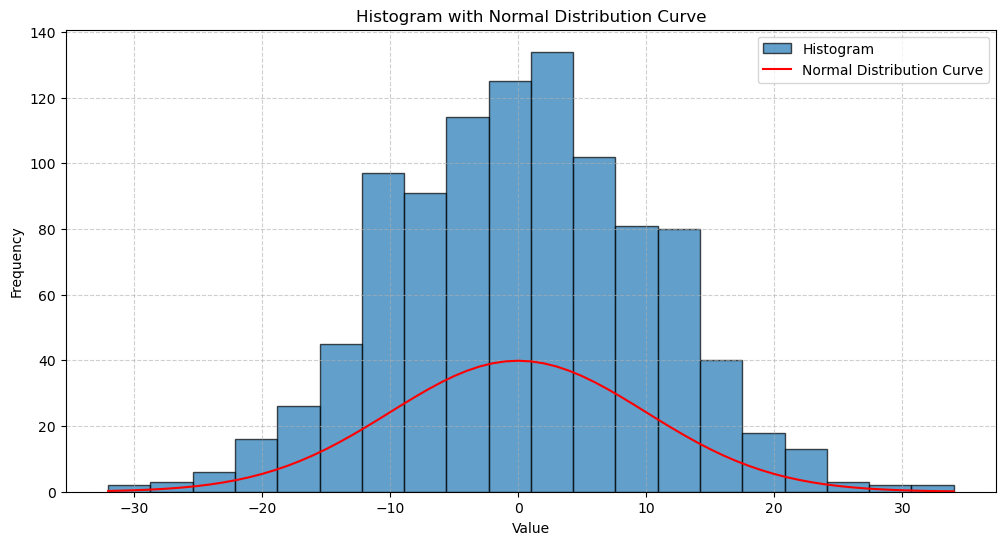

In [614]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate normally distributed integers
normal_integers = np.random.normal(loc=0, scale=10, size=1000)
normal_integers = np.round(normal_integers).astype(int)

# Generate data for the line (fitted normal distribution)
x = np.arange(min(normal_integers), max(normal_integers) + 1)
pdf = norm.pdf(x, loc=0, scale=10)  # Normal PDF based on the original distribution
pdf_scaled = pdf * len(normal_integers) * (x[1] - x[0])  # Scale to match histogram

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(normal_integers, bins=20, edgecolor='black', alpha=0.7, label='Histogram')

# Overlay the line
plt.plot(x, pdf_scaled, color='red', label='Normal Distribution Curve')

# Add labels and title
plt.title('Histogram with Normal Distribution Curve')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()



The usual process to understand a distribution is by dividing the data into ranges (also called "bins"), and then counting the number of values in each range. This is what the histogram shows. Let us see how this works.

In [615]:
earthquakes['Magnitude'].value_counts(bins=4)

(5.495, 6.4]    21084
(6.4, 7.3]       2023
(7.3, 8.2]        269
(8.2, 9.1]         13
Name: count, dtype: int64

This code uses the `value_counts` method to count the number of earthquake magnitudes into four bins (`bins=4`), and returns a series with the counts. Any numerical columns in a dataframe can be divided into bins using this method.

We can also plot the histogram for the `Magnitude` column using the `plot` method and the `hist` plot kind.

<Axes: title={'center': 'Earthquakes Magnitude Distribution'}, ylabel='Frequency'>

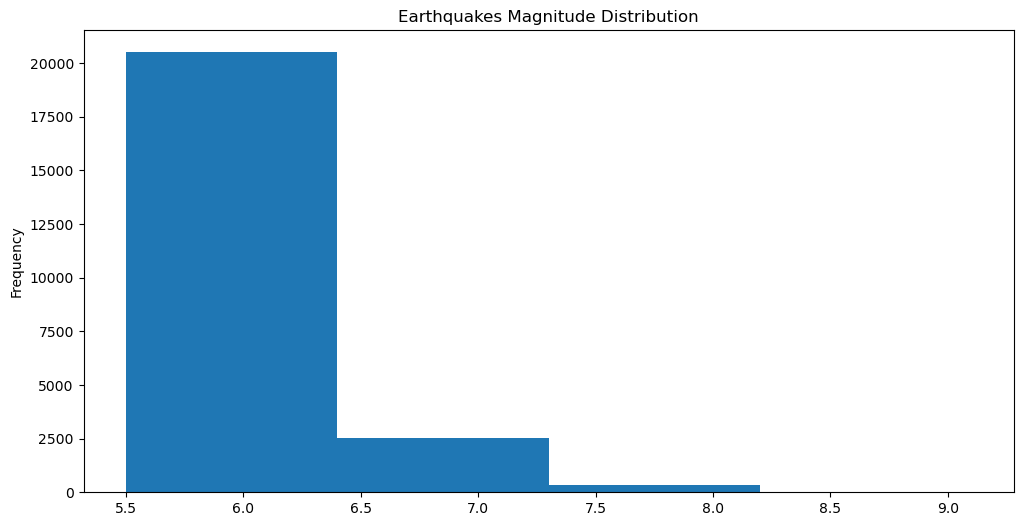

In [616]:
earthquakes['Magnitude'].plot(
    kind='hist',
    bins=4,
    title='Earthquakes Magnitude Distribution',
    figsize=(12, 6)
)

This creates a compelling visualisation of the distribution of magnitudes, and we can see there are a lot of earthquakes with small magnitudes!

### Understanding the relationship between variables

Another important aspect of data analysis is understanding the relationship between variables. This can be done by computing the correlation between variables, which measures how closely related two variables are. The correlation coefficient ranges from -1 to 1, where -1 indicates a perfect negative correlation, 1 indicates a perfect positive correlation, and 0 indicates no correlation.

Pandas offers a `corr` method to compute the correlation between variables. Let us see how this works.

In [617]:
earthquakes[
    ['Magnitude', 'Depth']
].corr()

,Magnitude,Depth
Magnitude,1.000000,0.023299
Depth,0.023299,1.000000


What the resulting matrix shows is the correlation between `Magnitude` and `Depth`, which is 0.023, indicating a very weak positive correlation. This means that as the magnitude of an earthquake increases, the depth of the earthquake also increases, but only very slightly.

We can run a similar analysis for any number of other columns, for example, let us add `Horizontal Error` to the mix.

In [618]:
earthquakes[
    ['Magnitude', 'Depth', 'Horizontal Error']
].corr()

,Magnitude,Depth,Horizontal Error
Magnitude,1.000000,0.023299,-0.128781
Depth,0.023299,1.000000,0.146771
Horizontal Error,-0.128781,0.146771,1.000000


Now we see a stronger correlation between `Depth` and `Horizontal Error`, which is 0.14. This means that as the depth of an earthquake increases, the horizontal error also increases, but again not by a large factor.

When performing this type of analysis between multiple columns, it is interesting to visualy represent the data. One way to do this is by using a scatter plot, which shows the relationship between two variables. Let us see how this works.

```{note}
Scatter plots are a very useful tool to visualize the relationship between two variables. They can help identify patterns and trends in the data, and can be used to identify outliers or anomalies. There are many other types of plots that can be used to visualize data, such as line plots, bar plots, and box plots, which we will use as we progress.
```

<Axes: title={'center': 'Earthquake Depth vs. Horizontal Error'}, xlabel='Depth', ylabel='Horizontal Error'>

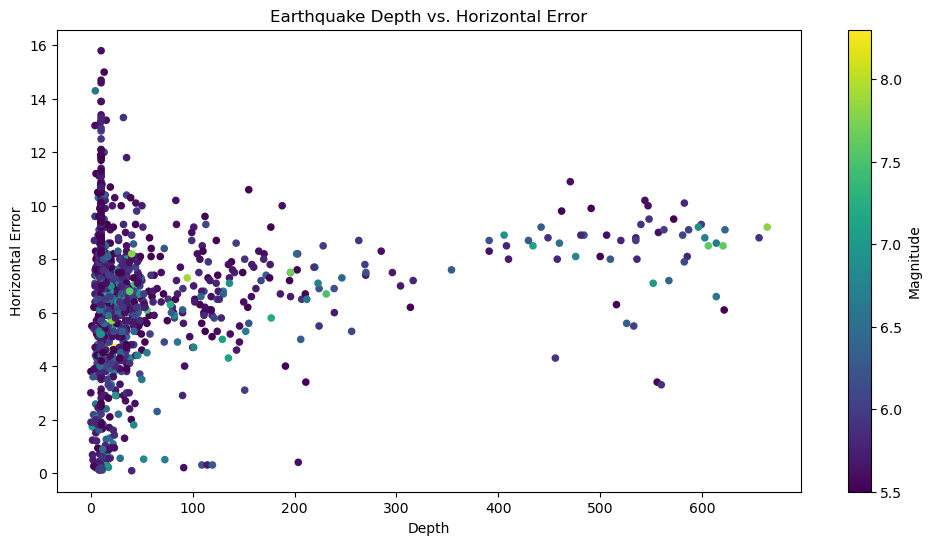

In [619]:
earthquakes.plot(
    kind='scatter',
    x='Depth',
    y='Horizontal Error',
    title='Earthquake Depth vs. Horizontal Error',
    cmap='viridis',
    c='Magnitude',
    figsize=(12, 6)
)

This plot is showing a visual representation of the correlation between `Depth` and `Horizontal Error`, and colored by `Magnitude`. We can see that there is no clear relationship between the two variables, which is consistent with the correlation coefficient we calculated earlier. The `c` argument is used to color the points by the `Magnitude` column, and the `cmap` argument is used to specify the color map to use. Let us do a similar plot for `Depth` and `Magnitude`.

### Categorical data and grouping

You will have noticed that some of the columns in the dataset are strings of text, such as `Type` and `Source`. These are called *categorical* data and can be used to group the data and perform analysis. Pandas offers a few methods to work with categorical data, such as `groupby` and `pivot_table`.

As an example, let us group the data by the `Type` column and calculate the average magnitude of each type of earthquake.

In [620]:
earthquakes.groupby(
    'Type'
)['Magnitude'].mean()

Type
Earthquake           5.882775
Explosion            5.850000
Nuclear Explosion    5.864417
Rock Burst           6.200000
Name: Magnitude, dtype: float64

What this series shows us is the average magnitude of each type of earthquake. For example, the average magnitude of `Earthquake` is aproximately 5.88, and the average magnitude of `Nuclear Explosion` is 5.86.

We can also use the `pivot_table` method to group the data by multiple columns. A pivot table is a way to summarize data in a table format, and can be used to perform more complex analysis. Let us see how this works, this time by grouping the data by `Type` and `Source`.

In [621]:
# Pivot Type and Magnitude
earthquakes.pivot_table(
    values='Magnitude',
    index=['Type', 'Source'],
    aggfunc='mean'
)

Magnitude
Type              Source              
Earthquake        AK          5.858333
                  CI          6.037778
                  GCMT        5.885455
                  ISCGEM      6.007805
                  ISCGEMSUP   6.000833
                  NC          6.029804
                  NN          5.725000
                  OFFICIAL    8.712500
                  PR          5.800000
                  SE          5.800000
                  US          5.865256
                  UW          5.966667
Explosion         US          5.850000
Nuclear Explosion US          5.864417
Rock Burst        US          6.200000

What this table shows us is the average magnitude of each type of earthquake, grouped by the source of the data, which is a more complex analysis than what we did before. A pivot table can be used to group data by multiple columns, and to perform more complex calculations, such as calculating the sum, mean, or median of a column. In the example above we used the `aggfunc` argument to specify that we want to calculate the mean of the `Magnitude` column. We could have used `aggfunc='median'` to calculate the median of the `Magnitude` column instead (`aggfunc` stands for "aggregation function").

### Using dates in our analysis

Let's now calculate the average magnitude of the earthquakes that occurred in a given year. If you look back at the data, you will see that the `Date` column contains the date and time of each earthquake. We can use this column to select a given year, and then calculate the average magnitude of the earthquakes that occurred in that year.

Notice however the `Date` format is an `object` type, which means that it is a string. We need to convert it to a `datetime` object to be able to extract the year. We can do this with the `to_datetime` method.

```{hint}
`datetime` objects are a very useful data type in Python, and Pandas offers a lot of functionality to work with them. You will come across them frequently when working with time series data, and it is good to be familiar with them.
```

In [622]:
earthquakes['Date'] = pd.to_datetime(
    earthquakes['Date'],
    format='%m/%d/%Y',
    errors='coerce'
)

The above looks a bit special, but it is actually quite simple. We are using the `to_datetime` method of the Pandas library to convert dates formated as 'month/day/year' (commonly used in the United States, unlike 'day/month/year' used in Europe) to a `datetime` object, with `errors='coerce'` instructing the method to return `NaT` (Not a Time) for any dates that cannot be converted.

Now let us extract the year from the `Date` column, and add it as a new column to the dataframe.

In [623]:
earthquakes['Year'] = earthquakes['Date'].dt.year

The above code uses the `dt` accessor to access the `year` attribute of the `Date` column, and then assigns it to a new column named `Year`.

```{hint}
An accessor is a way to access the elements of a data structure. In this case, the `dt` accessor is used to access the elements of a `datetime` object, such as the year, month, day, etc. Accessors are useful when working with data structures that contain complex data types, such as `datetime` objects.
```

We can now check the dataframe to see if the `Year` column was added.

In [624]:
earthquakes['Year']

0        1965.0
1        1965.0
2        1965.0
3        1965.0
4        1965.0
          ...  
23384    2016.0
23385    2016.0
23386    2016.0
23387    2016.0
23388    2016.0
Name: Year, Length: 23389, dtype: float64

Worked! Now that we have a `Year` column, we can calculate the average magnitude of the earthquakes that occurred in a given year.

In [625]:
earthquakes[earthquakes['Year'] == 1972]['Magnitude'].mean()

5.943814432989692

Great! We can even plot some of this data in interesting ways using the `matplotlib` library. Let us see how to do this.

<Axes: title={'center': 'Earthquakes in 1972'}, xlabel='Date', ylabel='Magnitude'>

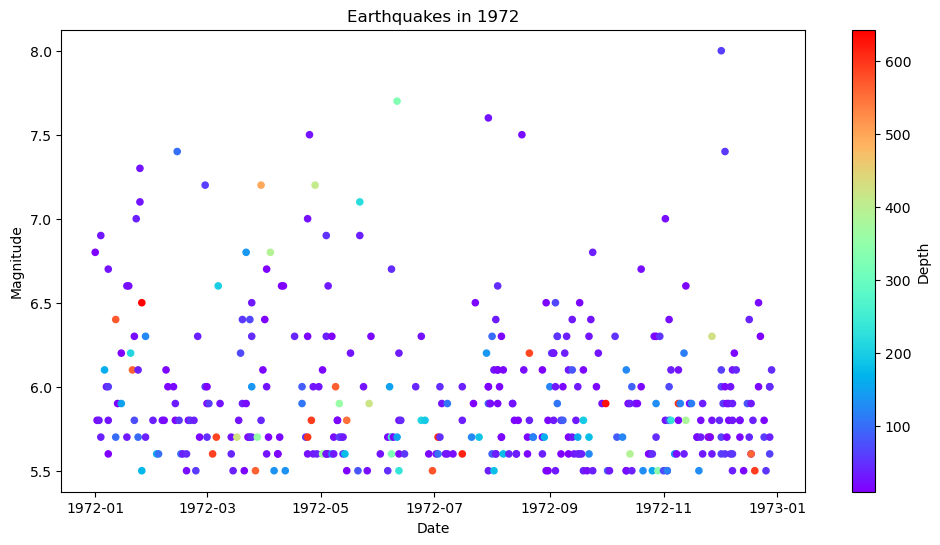

In [626]:
earthquakes[earthquakes['Year'] == 1972].plot(
    kind='scatter',
    x='Date',
    y='Magnitude',
    title='Earthquakes in 1972',
    colormap='rainbow',
    c='Depth',
    figsize=(12, 6)
)

Here we are plotting the Date vs the Magnitude of the earthquakes. The `plot` method is used to create the plot, and the `scatter` plot kind is used to create a scatter plot. The `c` argument is used to color the points by the `Depth` column, and the `cmap` argument is used to specify the color map to use. The `x` and `y` attributes are used to set the columns for the x and y axes, and the `title` method is used to set the title of the plot.

We can also use the `plot` method to create a line plot, which shows the relationship between two variables over time. We could for example plot the average magnitude of earthquakes over time by aggregating the data by a given time period.

<Axes: title={'center': 'Average Earthquake Magnitude per Year'}, xlabel='Date', ylabel='Average Magnitude'>

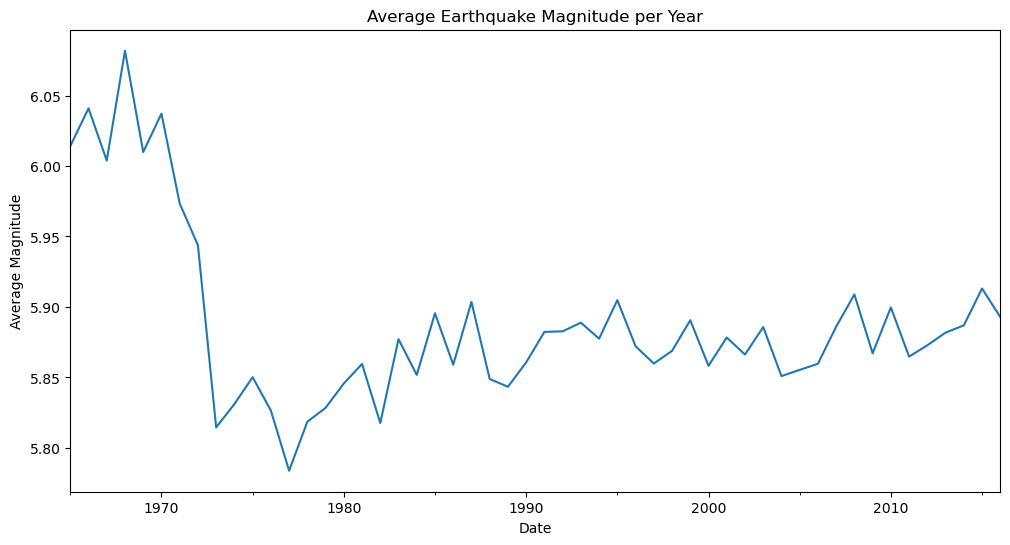

In [627]:
avg_magnitude_per_year = earthquakes.resample(
    rule='YE',
    on='Date'
)['Magnitude'].mean()

avg_magnitude_per_year.plot(
    kind='line',
    title='Average Earthquake Magnitude per Year',
    ylabel='Average Magnitude',
    figsize=(12, 6)
)

In the above code, we are taking a few steps:

- We are resampling the data by year using the `resample` method (`rule='YE'` means that we are resampling by year).
- We are calculating the mean of the `Magnitude` column for each year using the `mean` method.
- We then use the `plot` method to create a line plot of the data.

To make this clearer, let us show the calculated `avg_magnitude_per_year` series for the first five years.

In [628]:
avg_magnitude_per_year.head(5)

Date
1965-12-31    6.014159
1966-12-31    6.040948
1967-12-31    6.003922
1968-12-31    6.081848
1969-12-31    6.009938
Name: Magnitude, dtype: float64

### Using geographical data effectively

You will have noticed (hopefully) that the dataset contains geographical data in the form of `Latitude` and `Longitude`. This data can be used to create maps and to perform spatial analysis. For example, we could create a map of the earthquakes in the dataset, or we could filter out the earthquakes that occurred in a given region of the planet.

Let us take a simple example, and filter out the earthquakes that occurred around the region of the Azores islands. We will consider the region to be between 36 and 42 degrees latitude, and between -31 and -24 degrees longitude.

In [629]:
azores_earthquakes = earthquakes[
    earthquakes['Latitude'].between(36, 42) &
    earthquakes['Longitude'].between(-31, -24)
]

azores_earthquakes

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,Year
5381,1980-01-01,16:42:40,38.815,-27.780,Earthquake,10.0,NaN,NaN,6.7,MS,...,NaN,NaN,NaN,NaN,USP00014TU,US,US,US,Reviewed,1980.0
9065,1988-07-22,21:16:04,39.862,-29.589,Earthquake,10.0,NaN,NaN,5.5,MW,...,NaN,NaN,NaN,1.00,USP0003J40,US,US,HRV,Reviewed,1988.0
9230,1988-11-21,16:55:53,37.938,-26.142,Earthquake,10.8,2.9,NaN,5.9,MW,...,NaN,NaN,NaN,0.90,USP0003P1Z,US,US,HRV,Reviewed,1988.0
9301,1989-01-21,02:52:20,38.147,-26.243,Earthquake,10.0,NaN,NaN,5.7,MW,...,NaN,NaN,NaN,0.80,USP0003R1R,US,US,HRV,Reviewed,1989.0
9512,1989-06-26,10:38:39,39.112,-28.242,Earthquake,11.3,NaN,NaN,5.9,MW,...,NaN,NaN,NaN,1.10,USP0003WP5,US,US,NC,Reviewed,1989.0
12920,1996-03-09,22:35:38,37.034,-24.374,Earthquake,10.0,NaN,NaN,5.7,MWC,...,NaN,NaN,NaN,1.20,USP0007EJ0,US,US,HRV,Reviewed,1996.0
13564,1997-06-27,04:39:53,38.334,-26.684,Earthquake,10.0,NaN,NaN,5.9,MWC,...,NaN,NaN,NaN,1.09,USP0008416,US,US,HRV,Reviewed,1997.0
14010,1998-07-09,05:19:07,38.650,-28.626,Earthquake,10.0,NaN,NaN,6.2,MWB,...,NaN,NaN,NaN,0.98,USP0008R70,US,US,US,Reviewed,1998.0
16548,2003-12-23,14:02:04,40.135,-29.692,Earthquake,10.0,NaN,282.0,5.6,MWC,...,60.8,NaN,NaN,0.91,USP000CFW0,US,US,HRV,Reviewed,2003.0
18364,2007-04-05,03:56:50,37.306,-24.621,Earthquake,14.0,NaN,627.0,6.3,MWC,...,23.5,NaN,NaN,0.82,USP000F8R5,US,US,GCMT,Reviewed,2007.0


The above code should be self explanatory - we are filtering the dataframe by selecting the rows where the `Latitude` is between 36 and 42 degrees, and the `Longitude` is between -31 and -24 degrees. Now that we have the list, let us calculate the minimum, maximum, and average magnitude of the earthquakes that occurred in this region.

In [630]:

azores_min_magnitude = azores_earthquakes['Magnitude'].min()
azores_max_magnitude = azores_earthquakes['Magnitude'].max()
azores_mean_magnitude = azores_earthquakes['Magnitude'].mean()

azores_min_magnitude, azores_max_magnitude, azores_mean_magnitude

(5.5, 6.7, 5.95)

```{note}
There's a neat type of plot called a `boxplot` that can be used to visualize the distribution of data. It shows the median, quartiles, and outliers of the data. We don't need to go into the details of how it works for now, but it is useful to know that it exists and that it can be used to visualize the distribution of a given column.
```

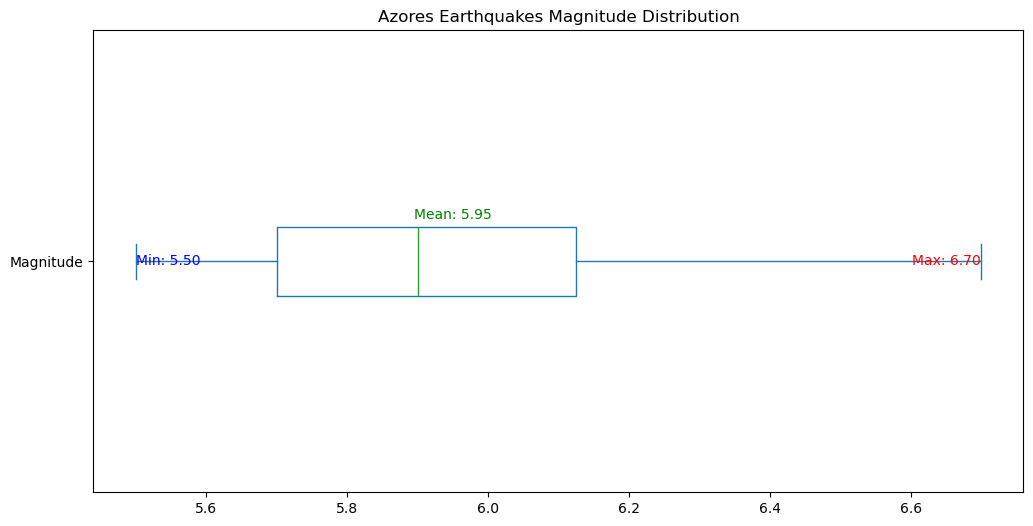

In [631]:
azores_earthquakes['Magnitude'].plot(
    kind='box',
    title='Azores Earthquakes Magnitude Distribution',
    figsize=(12, 6),
    vert=False
)

plt.text(azores_min_magnitude, 1, f'Min: {azores_min_magnitude:.2f}', va='center', ha='left', color='blue')
plt.text(azores_max_magnitude, 1, f'Max: {azores_max_magnitude:.2f}', va='center', ha='right', color='red')
plt.text(azores_mean_magnitude, 1.1, f'Mean: {azores_mean_magnitude:.2f}', va='center', ha='center', color='green')
plt.show()

Because we have a small dataset, we can also plot the earthquakes on a map. For this we will use the `folium` library which we can install with the `conda` command (by now you should be able to do this without further instruction).

In [632]:
import folium

# Create a map centered around the Azores
azores_map = folium.Map(
    location=[38, -28],
    zoom_start=6
)

# Add markers for each earthquake
for _, row in azores_earthquakes.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Magnitude'],  # Scale the circle size by magnitude
        color='blue',
        fill=True,
        fill_opacity=0.3,
        popup=f"Year: {int(row['Year'])} Magnitude: {row['Magnitude']}, Depth: {row['Depth']} km"
    ).add_to(azores_map)

# Display the map
azores_map

The code above produces an interactive map which you can zoom in and out of, and click on the markers to see the details of the earthquakes. To do so we follow a few steps:

- We create a `Map` object using the `folium` library, and set the center of the map roughly to the Azores islands.
- We iterate over the rows of the `azores_earthquakes` dataframe with a `for` loop, and add a marker for each earthquake to the map.
- We then display the map.

## Exercises

1. Calculate the average depth of the earthquakes that occurred in a given year.
2. Calculate the average number of stations that recorded an earthquake (you can uniquely identify an earthquake with the `ID` column) in a given year.
3. Calculate the average magnitude of the earthquakes that occurred in a given year, grouped by the `Type` column.
4. Explain the above code that creates a map of the earthquakes in the dataset. What does each line do?